# Machine Translation - Data

We inspect the dataset of WMT17 (zh-en).

In [35]:
import os, json, math, time
import dotenv
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    AutoModelForSeq2SeqLM,
    GenerationConfig,
)
import torch
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import jsonlines
from joblib import delayed, Parallel

dotenv.load_dotenv('.env')

True

## Load Dataset WMT17

| Field                                   | Value                                                                                            |
| --------------------------------------- | ------------------------------------------------------------------------------------------------ |
| Release year                            | 2017                                                                                             |
| Language pair                           | Chinese ↔ English (zh-en)                                                                        |
| Parallel sentences – Train              | 25 136 609                                                                                       |
| Parallel sentences – Dev (valid)        | 2 002                                                                                            |
| Parallel sentences – Test (newstest-17) | 2 001                                                                                            |
| Approx. download size                   | 884 MiB                                                                                          |
| De-compressed size                      | 6.4 GiB                                                                                          |
| Main sources                            | UN Parallel Corpus v1.0, News Commentary v12, CWMT corpus, WikiTitles, etc.                      |
| Domain                                  | News + mixed web crawl                                                                           |
| Tokenisation                            | raw text + SGML/TXT parallel files; no forced segmentation provided                              |
| Evaluation metric reported              | BLEU (baseline ≈ 17–18 on test set)                                                              |

Table from GenAI (Kimi.com)



In [36]:
data = load_dataset("wmt17", name='zh-en', split="train", cache_dir='./cache')


In [37]:
data

Dataset({
    features: ['translation'],
    num_rows: 25134743
})

In [38]:
data['translation']

Column([{'en': '1929 or 1989?', 'zh': '1929年还是1989年?'}, {'en': 'PARIS – As the economic crisis deepens and widens, the world has been searching for historical analogies to help us understand what has been happening.', 'zh': '巴黎-随着经济危机不断加深和蔓延，整个世界一直在寻找历史上的类似事件希望有助于我们了解目前正在发生的情况。'}, {'en': 'At the start of the crisis, many people likened it to 1982 or 1973, which was reassuring, because both dates refer to classical cyclical downturns.', 'zh': '一开始，很多人把这次危机比作1982年或1973年所发生的情况，这样得类比是令人宽心的，因为这两段时期意味着典型的周期性衰退。'}, {'en': 'Today, the mood is much grimmer, with references to 1929 and 1931 beginning to abound, even if some governments continue to behave as if the crisis was more classical than exceptional.', 'zh': '如今人们的心情却是沉重多了，许多人开始把这次危机与1929年和1931年相比，即使一些国家政府的表现仍然似乎把视目前的情况为是典型的而看见的衰退。'}, {'en': 'The tendency is either excessive restraint (Europe) or a diffusion of the effort (the United States).', 'zh': '目前的趋势是，要么是过度的克制（欧洲），要么是努力的扩展（美国）。'}])

In [39]:
len(data['translation'])

25134743

## Inspect a Subset

In [40]:
random.seed(111)
subset = random.choices(data['translation'], k=256)

In [41]:
subset[0]

{'en': 'Also sink most perhaps and equally, the most helpless!',
 'zh': '也许同样也是最沉, 最无奈吧!'}

## Sentence Length

In [42]:
df = pd.DataFrame.from_records(subset)

In [43]:
df.to_csv('./data-samples.csv', index=False)

In [44]:
df_len = pd.DataFrame({
    'en': df.en.str.len(),
    'zh': df.zh.str.len(),
})

Text(0.5, 0.98, 'Sentence length distributions')

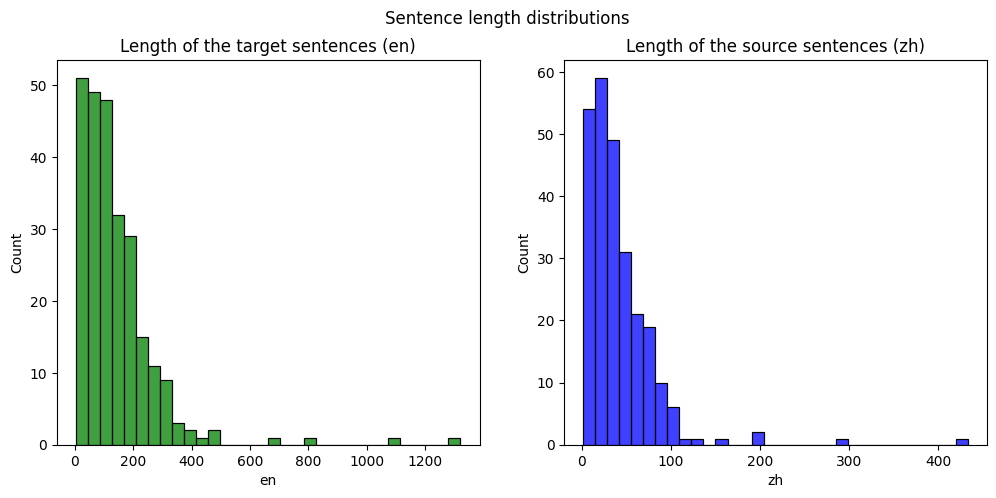

In [45]:
plt.figure(figsize=(12,5))
ax=plt.subplot(121)
sns.histplot(df_len.en, color='green', ax=ax)
plt.title('Length of the target sentences (en)')
ax=plt.subplot(122)
sns.histplot(df_len.zh, color='blue', ax=ax)
plt.title('Length of the source sentences (zh)')
plt.suptitle('Sentence length distributions')

We can see that the average length of English sentences are roughly 4 times of the Chinese sentence lengths.

In [46]:
df_len.describe()

,en,zh
count,256.000000,256.000000
mean,140.640625,42.152344
std,143.668531,41.888042
min,4.000000,2.000000
25%,52.750000,18.000000
50%,110.000000,32.500000
75%,187.000000,54.250000
max,1322.000000,433.000000


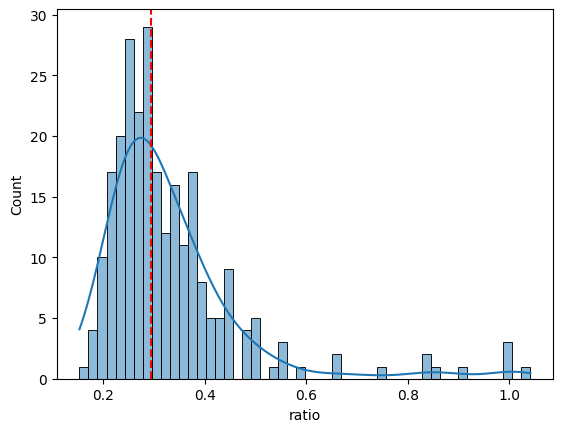

In [47]:
df_len['ratio'] = df_len.zh / (df_len.en + 1e-3)
sns.histplot(df_len.ratio, bins=50, kde=True)
plt.axvline(df_len.ratio.median(), color='r', ls='--')

## Word Clouds

Chinese stopwords from https://github.com/goto456/stopwords/blob/master/cn_stopwords.txt

In [48]:
from wordcloud import WordCloud, STOPWORDS
import jieba, numpy as np, PIL.Image as Image

STOPWORDS_ZH = set(open('./cn_stopwords.txt').read().splitlines())
STOPWORDS_ZH.add('中')

In [49]:
STOPWORDS_ZH

{'$',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '?',
 '_',
 '“',
 '”',
 '、',
 '。',
 '《',
 '》',
 '一',
 '一些',
 '一何',
 '一切',
 '一则',
 '一方面',
 '一旦',
 '一来',
 '一样',
 '一般',
 '一转眼',
 '万一',
 '上',
 '上下',
 '下',
 '不',
 '不仅',
 '不但',
 '不光',
 '不单',
 '不只',
 '不外乎',
 '不如',
 '不妨',
 '不尽',
 '不尽然',
 '不得',
 '不怕',
 '不惟',
 '不成',
 '不拘',
 '不料',
 '不是',
 '不比',
 '不然',
 '不特',
 '不独',
 '不管',
 '不至于',
 '不若',
 '不论',
 '不过',
 '不问',
 '与',
 '与其',
 '与其说',
 '与否',
 '与此同时',
 '且',
 '且不说',
 '且说',
 '两者',
 '个',
 '个别',
 '中',
 '临',
 '为',
 '为了',
 '为什么',
 '为何',
 '为止',
 '为此',
 '为着',
 '乃',
 '乃至',
 '乃至于',
 '么',
 '之',
 '之一',
 '之所以',
 '之类',
 '乌乎',
 '乎',
 '乘',
 '也',
 '也好',
 '也罢',
 '了',
 '二来',
 '于',
 '于是',
 '于是乎',
 '云云',
 '云尔',
 '些',
 '亦',
 '人',
 '人们',
 '人家',
 '什么',
 '什么样',
 '今',
 '介于',
 '仍',
 '仍旧',
 '从',
 '从此',
 '从而',
 '他',
 '他人',
 '他们',
 '以',
 '以上',
 '以为',
 '以便',
 '以免',
 '以及',
 '以故',
 '以期',
 '以来',
 '以至',
 '以至于',
 '以致',
 '们',
 '任',
 '任何',
 '任凭',
 '似的',
 '但',
 '但凡',
 '但是',
 '何',
 '何以',
 '何况',
 '何处',
 '何时',
 '余外',
 '作为',
 '你',

In [50]:

zh_txt = ' '.join([' '.join(jieba.lcut(s)) for s in df.zh])
en_txt = ' '.join(df.en.str.lower().tolist())
wc_zh = WordCloud(font_path='SimHei.ttf', width=400,
                  background_color='white', stopwords=STOPWORDS_ZH).generate(zh_txt)
wc_en = WordCloud(width=400, background_color='white',
                  stopwords=STOPWORDS).generate(en_txt)

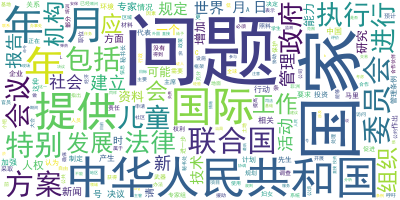

In [51]:
wc_zh.to_image()


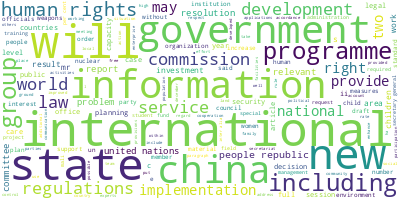

In [52]:
wc_en.to_image()

In [53]:
combo = np.hstack([wc_zh.to_array(), wc_en.to_array()])
Image.fromarray(combo).save('bilingual_cloud.png')